<a href="https://colab.research.google.com/github/vinothkumard2006-ai/Practice-in-colab/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.listdir('/content/drive/MyDrive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['Untitled spreadsheet.gsheet',
 'job survey.gsheet',
 'final_combined_enriched_v4.csv',
 'Colab Notebooks',
 'Medicinal plant dataset']

In [ ]:
import tensorflow as tf
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
from tensorflow.keras import layers, models

# Step 1: Load dataset
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/Medicinal plant dataset", # Changed the path to a local Google Drive path
    image_size=(224,224),
    batch_size=32,
    shuffle=True
)

class_names = dataset.class_names
print("Plant Classes:", class_names)

# Step 2: Train-test split
train_size = int(0.8 * len(dataset))
train_ds = dataset.take(train_size)
test_ds = dataset.skip(train_size)

# Step 3: Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Step 4: Build CNN model with normalization + augmentation inside
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224,224,3)),   # normalization
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation="softmax")
])

# Step 5: Compile
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Step 6: Train
history = model.fit(train_ds, validation_data=test_ds, epochs=20)

# Step 7: Evaluate
loss, acc = model.evaluate(test_ds)
print(f"Test Accuracy: {acc:.2f}")

Found 5945 files belonging to 40 classes.
Plant Classes: ['Aloevera', 'Amla', 'Amruta_Balli', 'Arali', 'Ashoka', 'Ashwagandha', 'Avacado', 'Bamboo', 'Basale', 'Betel', 'Betel_Nut', 'Brahmi', 'Castor', 'Curry_Leaf', 'Doddapatre', 'Ekka', 'Ganike', 'Gauva', 'Geranium', 'Henna', 'Hibiscus', 'Honge', 'Insulin', 'Jasmine', 'Lemon', 'Lemon_grass', 'Mango', 'Mint', 'Nagadali', 'Neem', 'Nithyapushpa', 'Nooni', 'Pappaya', 'Pepper', 'Pomegranate', 'Raktachandini', 'Rose', 'Sapota', 'Tulasi', 'Wood_sorel']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 68s 224ms/step - accuracy: 0.0397 - loss: 5.1714 - val_accuracy: 0.1001 - val_loss: 3.4447
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.0811 - loss: 3.4664 - val_accuracy: 0.1406 - val_loss: 3.1877
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.1334 - loss: 3.2113 - val_accuracy: 0.1977 - val_loss: 2.9530
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.1639 - loss: 3.0566 - val_accuracy: 0.2572 - val_loss: 2.7588
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.2052 - loss: 2.8751 - val_accuracy: 0.3259 - val_loss: 2.4795
Epoch 6/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.2403 - loss: 2.6793 - val_accuracy: 0.3482 - val_loss: 2.3572
Epoch 7/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.2739 - loss: 2.5470 - val_accuracy: 0.3929 - val_loss: 2.1401
Epoch 8/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.3085 - loss: 2.4071 - val_ac

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


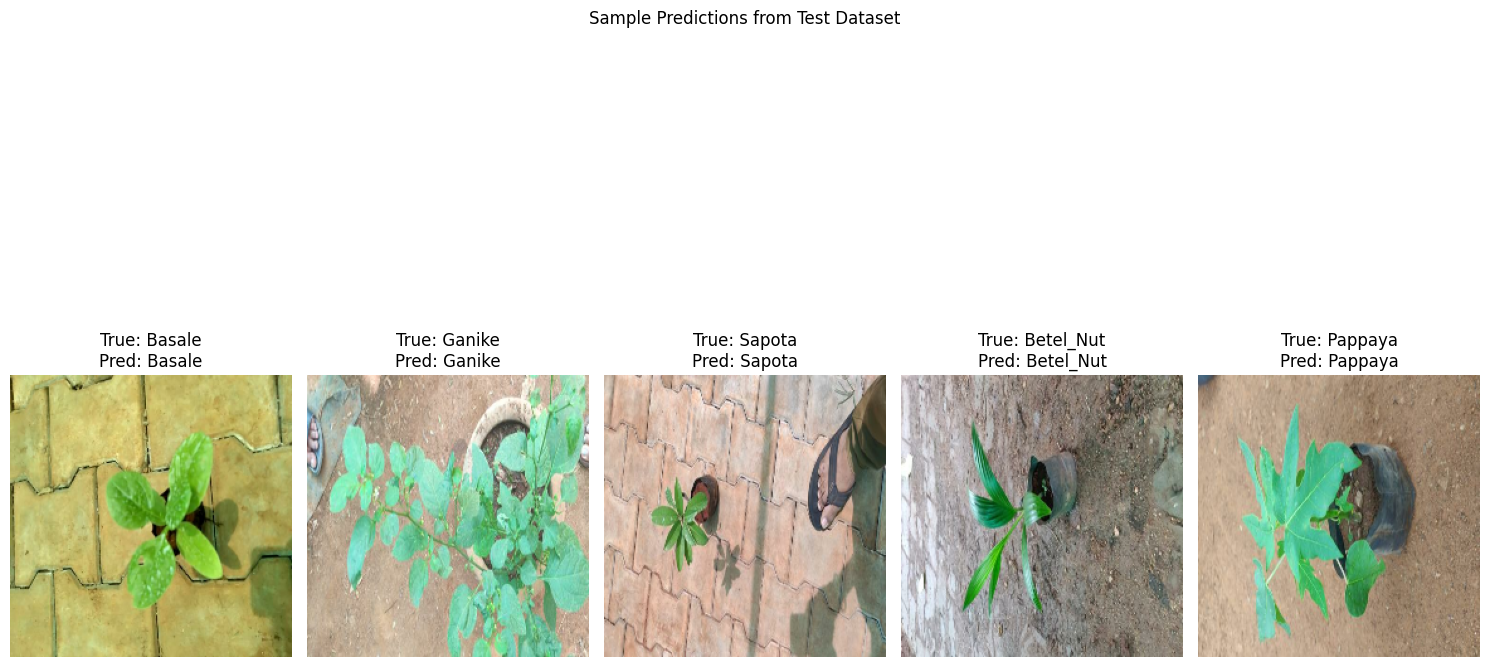

Predictions on a sample of the test dataset displayed.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Obtain a batch of images and their corresponding true labels from the test_ds
# Convert test_ds to a NumPy iterator and get one batch
for images, labels in test_ds.take(1):
    sample_images = images.numpy()
    sample_labels = labels.numpy()

# 2. Use the trained model to make predictions on these images
predictions = model.predict(sample_images)

# 3. For each image in the batch, determine the predicted class
predicted_classes = np.argmax(predictions, axis=1)
predicted_class_names = [class_names[idx] for idx in predicted_classes]
true_class_names = [class_names[idx] for idx in sample_labels]

# 4. Display a few sample images along with their true labels and predicted labels
plt.figure(figsize=(15, 10))
for i in range(min(5, len(sample_images))): # Display up to 5 samples
    plt.subplot(1, 5, i + 1)
    plt.imshow(sample_images[i] / 255.0) # Normalize to [0, 1] for float images
    plt.title(f"True: {true_class_names[i]}\nPred: {predicted_class_names[i]}")
    plt.axis('off')
plt.suptitle('Sample Predictions from Test Dataset')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("Predictions on a sample of the test dataset displayed.")

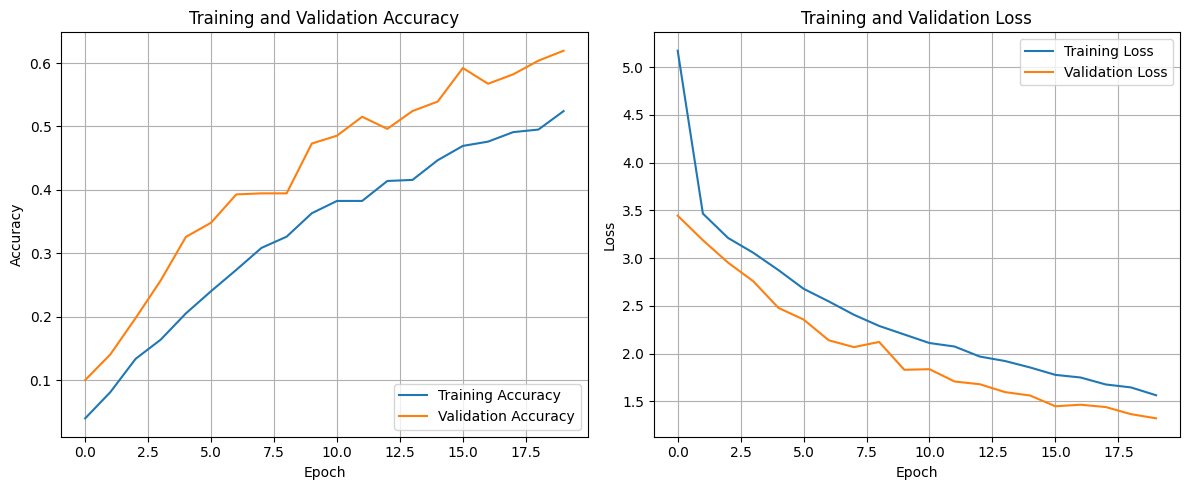

In [ ]:
import matplotlib.pyplot as plt

# Get training history data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Plot Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.applications import MobileNetV2

# Instantiate MobileNetV2 model
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False, # Exclude the top classification layer
    weights='imagenet'
)

# Display the model summary to verify its structure
base_model.summary()
print("Pre-trained MobileNetV2 model loaded successfully as a feature extractor.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

Pre-trained MobileNetV2 model loaded successfully as a feature extractor.


In [ ]:
base_model.trainable = False
print("MobileNetV2 base model layers frozen successfully.")

MobileNetV2 base model layers frozen successfully.


In [ ]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model.summary()
print("Custom classification layers added and new model created successfully.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 40)             │         5,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,112 (9.26 MB)

 Trainable params: 169,128 (660.66 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Custom classification layers added and new model created successfully.


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

history_fine_tune = model.fit(train_ds, validation_data=test_ds, epochs=10)

print("Model training completed.")

Model compiled successfully.
Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 81s 306ms/step - accuracy: 0.0547 - loss: 3.6310 - val_accuracy: 0.1456 - val_loss: 3.3924
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.1132 - loss: 3.3010 - val_accuracy: 0.2457 - val_loss: 3.1003
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.1691 - loss: 3.0464 - val_accuracy: 0.2854 - val_loss: 2.7923
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.2016 - loss: 2.8644 - val_accuracy: 0.3391 - val_loss: 2.5932
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.2413 - loss: 2.7117 - val_accuracy: 0.3788 - val_loss: 2.4498
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.2635 - loss: 2.5952 - val_accuracy: 0.4053 - val_loss: 2.3109
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.2861 - loss: 2.5189 - val_accuracy: 0.4376 - val_loss: 2.1755
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4640 - loss: 2.0285
Test Loss: 2.0285
Test Accuracy: 0.4640


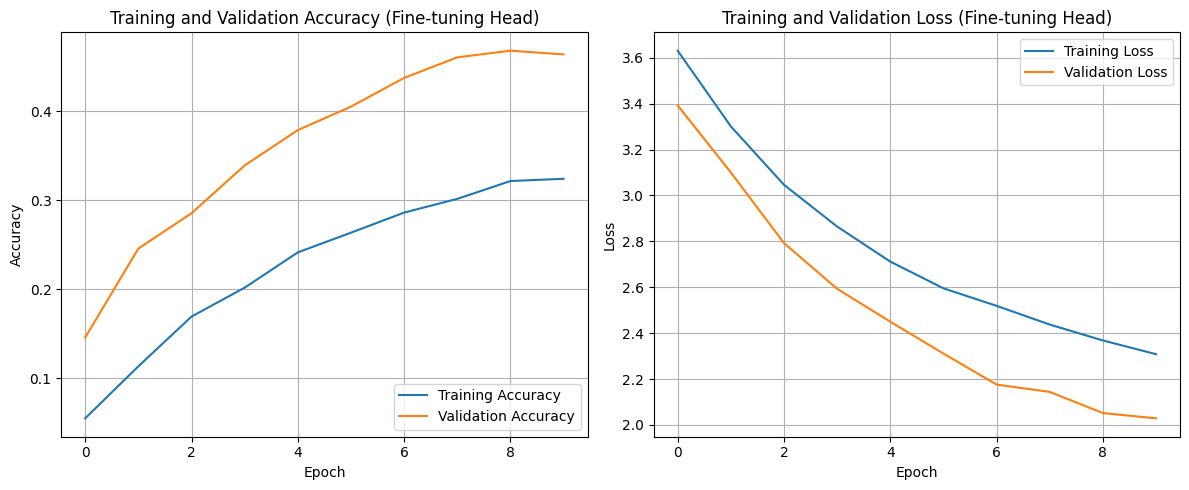

Model performance evaluated and visualized successfully.


In [ ]:
import matplotlib.pyplot as plt

# Evaluate the model on the test set
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Get training history data
acc = history_fine_tune.history['accuracy']
val_acc = history_fine_tune.history['val_accuracy']
loss = history_fine_tune.history['loss']
val_loss = history_fine_tune.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (Fine-tuning Head)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Plot Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (Fine-tuning Head)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Model performance evaluated and visualized successfully.")

In [ ]:
base_model.trainable = True

# Freeze the first 100 layers
for layer in base_model.layers[:100]:
    layer.trainable = False

print(f"Base model set to trainable. First {len([layer for layer in base_model.layers if not layer.trainable])} layers are frozen.")

Base model set to trainable. First 100 layers are frozen.


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model recompiled with a low learning rate.")

history_fine_tune_full = model.fit(train_ds, validation_data=test_ds, epochs=10)

print("Fine-tuning training completed.")

Model recompiled with a low learning rate.
Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 93s 216ms/step - accuracy: 0.0509 - loss: 5.0033 - val_accuracy: 0.3375 - val_loss: 2.3304
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.0999 - loss: 3.3369 - val_accuracy: 0.3184 - val_loss: 2.4266
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.1448 - loss: 3.0554 - val_accuracy: 0.2953 - val_loss: 2.4841
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.1822 - loss: 2.8777 - val_accuracy: 0.2647 - val_loss: 2.6186
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.2299 - loss: 2.6856 - val_accuracy: 0.2448 - val_loss: 2.7281
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.2540 - loss: 2.5465 - val_accuracy: 0.2399 - val_loss: 2.7921
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2967 - loss: 2.4177 - val_accuracy: 0.2622 - val_loss: 2.7223
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2887 - loss: 2.5548
Test Loss after fine-tuning: 2.5548
Test Accuracy after fine-tuning: 0.2887


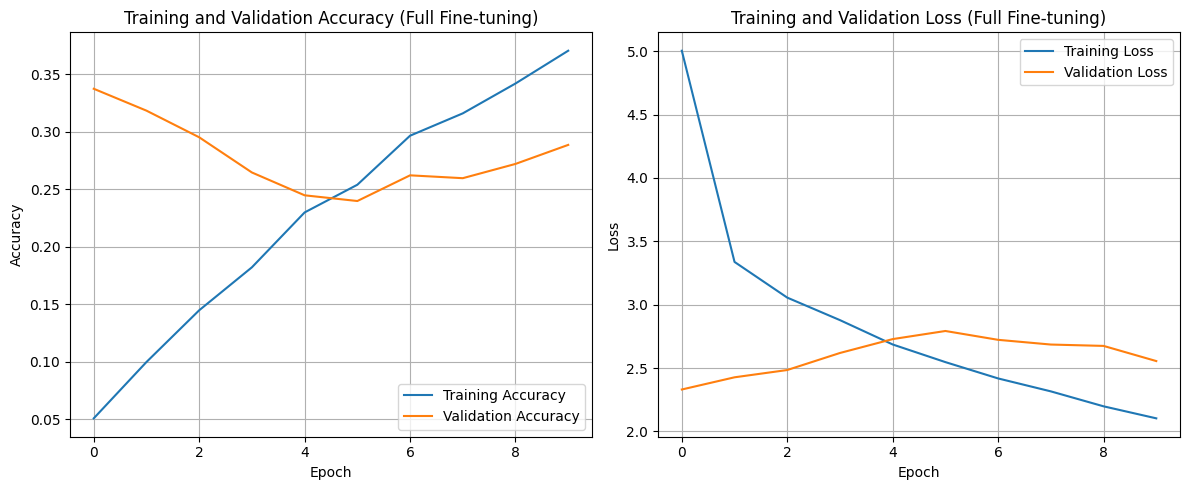

Fine-tuned model performance evaluated and visualized successfully.


In [ ]:
import matplotlib.pyplot as plt

# Evaluate the model on the test set after fine-tuning
loss_full, accuracy_full = model.evaluate(test_ds)
print(f"Test Loss after fine-tuning: {loss_full:.4f}")
print(f"Test Accuracy after fine-tuning: {accuracy_full:.4f}")

# Get training history data for the full fine-tuning phase
acc_full = history_fine_tune_full.history['accuracy']
val_acc_full = history_fine_tune_full.history['val_accuracy']
loss_full_hist = history_fine_tune_full.history['loss']
val_loss_full = history_fine_tune_full.history['val_loss']
epochs_range_full = range(len(acc_full))

plt.figure(figsize=(12, 5))

# Plot Training and Validation Accuracy for fine-tuning phase
plt.subplot(1, 2, 1)
plt.plot(epochs_range_full, acc_full, label='Training Accuracy')
plt.plot(epochs_range_full, val_acc_full, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (Full Fine-tuning)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Plot Training and Validation Loss for fine-tuning phase
plt.subplot(1, 2, 2)
plt.plot(epochs_range_full, loss_full_hist, label='Training Loss')
plt.plot(epochs_range_full, val_loss_full, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (Full Fine-tuning)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Fine-tuned model performance evaluated and visualized successfully.")